In [1]:
# Import packages
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import (
    roc_curve, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, accuracy_score, recall_score, f1_score
)

In [ ]:
# Import the lending club dataset with a cursory examination
REPO_ROOT = Path(__file__).resolve().parent.parent    
LOANS_CSV = REPO_ROOT / "Datasets" / "LC_loans_unrate_credit.csv"
OUT = Path(__file__).resolve().parent

df = pd.read_csv(LOANS_CSV)
df.head()


,id,revenue,dti_n,loan_amnt,fico_n,experience_c,emp_length,purpose,home_ownership_n,addr_state,zip_code,Default,title,desc,unemployment_rate,credit_spread,issue_d
0,68407277,55000.0,5.91,3600,677.0,1,10+ years,debt_consolidation,MORTGAGE,PA,190xx,0,Debt consolidation,Unknown,5.1,3.212273,Dec-2015
1,68355089,65000.0,16.06,24700,717.0,1,10+ years,small_business,MORTGAGE,SD,577xx,0,Business,Unknown,5.1,3.212273,Dec-2015
2,68341763,71000.0,13.85,20000,697.0,1,10+ years,home_improvement,MORTGAGE,IL,605xx,0,Unknown,Unknown,5.1,3.212273,Dec-2015
3,68476807,104433.0,25.37,10400,697.0,1,3 years,major_purchase,MORTGAGE,PA,174xx,0,Major purchase,Unknown,5.1,3.212273,Dec-2015
4,68426831,34000.0,10.20,11950,692.0,1,4 years,debt_consolidation,RENT,GA,300xx,0,Debt consolidation,Unknown,5.1,3.212273,Dec-2015


In [3]:
# Inspect variables
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1347681 entries, 0 to 1347680
Data columns (total 17 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   id                 1347681 non-null  int64  
 1   revenue            1347681 non-null  float64
 2   dti_n              1347681 non-null  float64
 3   loan_amnt          1347681 non-null  int64  
 4   fico_n             1347681 non-null  float64
 5   experience_c       1347681 non-null  int64  
 6   emp_length         1347681 non-null  object 
 7   purpose            1347681 non-null  object 
 8   home_ownership_n   1347681 non-null  object 
 9   addr_state         1347681 non-null  object 
 10  zip_code           1347681 non-null  object 
 11  Default            1347681 non-null  int64  
 12  title              1347681 non-null  object 
 13  desc               1347681 non-null  object 
 14  unemployment_rate  1347681 non-null  float64
 15  credit_spread      1347681 non-n

In [4]:
# Inspect ranges for quantitative variables
df.describe()

,id,revenue,dti_n,loan_amnt,fico_n,experience_c,Default,unemployment_rate,credit_spread
count,1.347681e+06,1.347681e+06,1.347681e+06,1.347681e+06,1.347681e+06,1.347681e+06,1.347681e+06,1.347681e+06,1.347681e+06
mean,5.621359e+07,7.736968e+04,1.829909e+01,1.440823e+04,6.981589e+02,9.999814e-01,1.997869e-01,5.629811e+00,2.668401e+00
std,3.839501e+07,7.036299e+04,1.115214e+01,8.715347e+03,3.184872e+01,4.306977e-03,3.998402e-01,1.218105e+00,4.528121e-01
min,5.473400e+04,1.896000e+03,0.000000e+00,5.000000e+02,6.120000e+02,0.000000e+00,0.000000e+00,3.700000e+00,1.594286e+00
25%,1.970651e+07,4.660000e+04,1.182000e+01,7.975000e+03,6.720000e+02,1.000000e+00,0.000000e+00,4.900000e+00,2.334762e+00
50%,5.766422e+07,6.500000e+04,1.763000e+01,1.200000e+04,6.920000e+02,1.000000e+00,0.000000e+00,5.200000e+00,2.680952e+00
75%,8.449505e+07,9.200000e+04,2.407000e+01,2.000000e+04,7.120000e+02,1.000000e+00,0.000000e+00,6.200000e+00,3.010476e+00
max,1.456364e+08,1.099920e+07,9.990000e+02,4.000000e+04,8.475000e+02,1.000000e+00,1.000000e+00,1.000000e+01,6.013636e+00


In [5]:
# Split data into training and testing data
ind_vars = ['revenue', 'dti_n', 'loan_amnt', 'fico_n', 'purpose', 'home_ownership_n', 'emp_length', 'experience_c', 'addr_state', 'zip_code', 'title', 'unemployment_rate', 'credit_spread']
dep_var = ['Default']

# Hold-out sample (latest 20% by issue_d) for PSI analysis later
num_rows = df.shape[0]
cutoff_row = int(np.round(0.8*num_rows))
df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y')
df = df.sort_values('issue_d').reset_index(drop=True)
ind_col_idx = df.columns.get_indexer(ind_vars)
dep_col_idx = df.columns.get_indexer(dep_var)
X_test_psi = df.iloc[cutoff_row:, ind_col_idx]
y_test_psi = df.iloc[cutoff_row:, dep_col_idx]
Xy_test_psi = X_test_psi.join(y_test_psi)

# Samples for model training and testing
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:cutoff_row, ind_col_idx], df.iloc[:cutoff_row, dep_col_idx], test_size=0.2, random_state=42)
Xy_train = X_train.join(y_train)
Xy_test = X_test.join(y_test)

In [6]:
# Function to compute IV for continuous variables, given a number of bins
def get_iv_conts(df: pd.DataFrame, column: str, num_bins: int) -> float:

  total_bads = df[df['Default'] == 1].shape[0]
  total_goods = df[df['Default'] == 0].shape[0]

  # Calculate WoE for each bin and IV for the chosen column
  pct_bad_list = []
  pct_good_list = []
  woe_list = []

  for i in range(num_bins):

      # Set upper and lower_bounds for bin
      lower_bound = df[column].quantile(i/num_bins)
      upper_bound = df[column].quantile((i+1)/num_bins)

      # Filter values in range
      filter = (df[column] <= upper_bound) & (df[column] > lower_bound)
      filtered_df = df[filter]

      # Count number of bads and goods for WoE calculation
      num_bads = filtered_df[filtered_df['Default'] == 1].shape[0]
      num_goods = filtered_df[filtered_df['Default'] == 0].shape[0]
      pct_bad = num_bads / total_bads
      pct_bad_list.append(pct_bad)
      pct_good = num_goods / total_goods
      pct_good_list.append(pct_good)

      # Calculate WoE for this bin, taking into account if pct_bad or pct_good is zero
      if pct_good == 0 or pct_bad == 0:
          raise ValueError('pct_good = 0 or pct_bad = 0 in a bin')
          return
      else:
          woe = np.log(pct_good/pct_bad)
          woe_list.append(woe)

  # Calculate IV for this variable
  iv = np.sum((np.array(pct_good_list) - np.array(pct_bad_list)) * np.array(woe_list))

  return iv

In [7]:
# Function to compute IV for discrete variables
def get_iv_disc(df: pd.DataFrame, column: str) -> float:

  total_bads = df[df['Default'] == 1].shape[0]
  total_goods = df[df['Default'] == 0].shape[0]

  grp = df.groupby(column)['Default']
  num_bads = grp.sum()
  num_goods = grp.count() - num_bads

  numerator = (num_goods + 0.5) / total_goods
  denominator = (num_bads + 0.5) / total_bads
  adjusted_woes = np.log(numerator / denominator)   # Series indexed by category

  pct_good = num_goods / total_goods
  pct_bad = num_bads / total_bads
  iv = np.sum((np.array(pct_good) - np.array(pct_bad)) * np.array(adjusted_woes))

  return iv

In [8]:
# Set columns for binning
total = Xy_train.shape[0]
conts_columns = ['revenue', 'dti_n', 'loan_amnt', 'fico_n', 'unemployment_rate', 'credit_spread']
disc_columns = ['purpose', 'emp_length', 'experience_c', 'addr_state', 'zip_code', 'home_ownership_n', 'title']

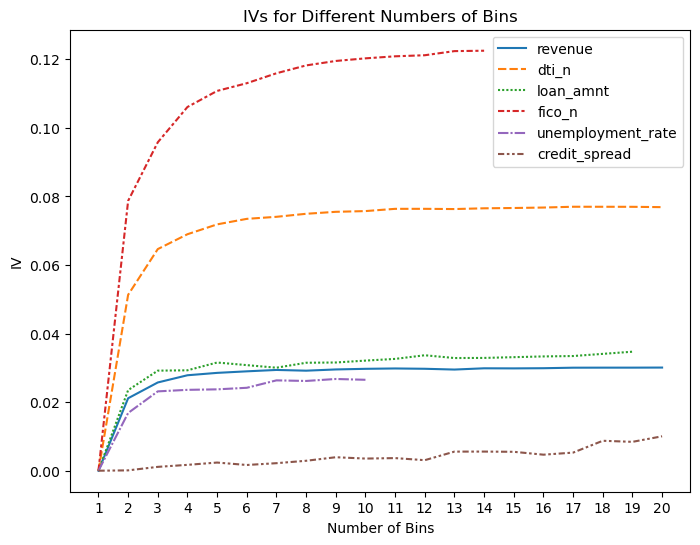

In [9]:
# Plotting graphs of IV against total number of bins for each continuous variable
max_bins = 20
num_bins_range = range(0, max_bins)
conts_iv_df = pd.DataFrame(index = num_bins_range, columns = conts_columns)

# Using the get_iv_conts function to obtain IVs for different total numbers of bins
for column in conts_columns:

  for num_bins in range(1, max_bins+1):

    try:
      iv = get_iv_conts(Xy_train, column, num_bins)
    except ValueError:
      continue
    conts_iv_df.loc[num_bins, column] = iv

# Setting plot features
plt.figure(figsize=(8, 6))
conts_ivs_plot = sns.lineplot(data=conts_iv_df)

plt.title('IVs for Different Numbers of Bins')
plt.xlabel('Number of Bins')
plt.ylabel('IV')
plt.xticks(range(1, max_bins + 1))
plt.legend()
plt.show()

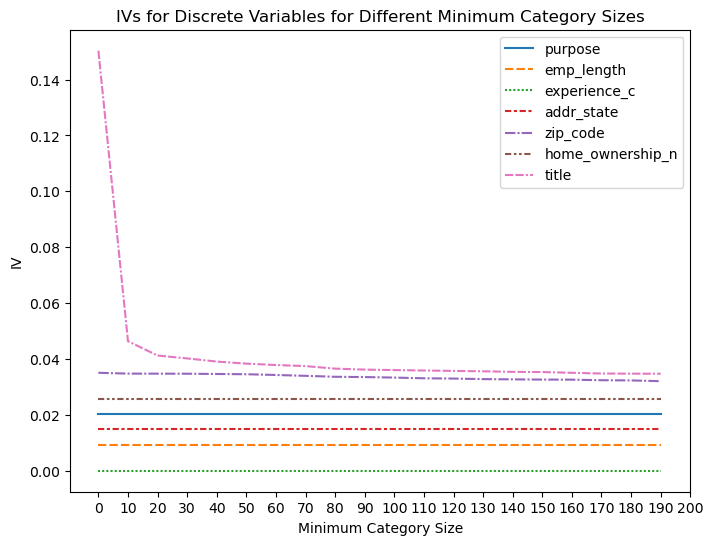

In [10]:
# Plotting graphs of IV against total number of bins for each discrete variable
disc_iv_df = pd.DataFrame(columns = disc_columns)
Xy_train_copy = Xy_train.copy()

# Using the get_iv_disc function to obtain IVs
for column in disc_columns:

  for i in range(20):
    
    counts = Xy_train_copy[column].value_counts()
    rare = counts[counts < 10*i].index

    Xy_train_copy[column] = Xy_train_copy[column].where(~Xy_train_copy[column].isin(rare), 'Other')
  
    try:
      iv = get_iv_disc(Xy_train_copy, column)
    except ValueError:
      continue
    disc_iv_df.loc[10*i, column] = iv

# Setting plot features
plt.figure(figsize=(8, 6))
disc_ivs_plot = sns.lineplot(data=disc_iv_df)

plt.title('IVs for Discrete Variables for Different Minimum Category Sizes')
plt.xlabel('Minimum Category Size')
plt.ylabel('IV')
plt.xticks(range(0, 210, 10))
plt.legend()
plt.show()

In [11]:
# Drop uninformative independent variables (IV < 0.02)
columns_to_drop = ['credit_spread', 'emp_length', 'experience_c', 'addr_state']
Xy_train.drop(columns=columns_to_drop, axis=1, inplace=True, errors='ignore')
Xy_test.drop(columns=columns_to_drop, axis=1, inplace=True, errors='ignore')
Xy_test_psi.drop(columns=columns_to_drop, axis=1, inplace=True, errors='ignore')

# Remove these variables from disc_columns and conts_columns
conts_columns.remove('credit_spread')
disc_columns.remove('emp_length')
disc_columns.remove('experience_c')
disc_columns.remove('addr_state')

In [12]:
# Merge categories for a minimum category size of 20 for Xy_train, Xy_test and Xy_test_psi
min_count = 20

for column in disc_columns:

    counts = Xy_train[column].value_counts()
    rare = counts[counts < min_count].index
    
    for frame in (Xy_train, Xy_test, Xy_test_psi):
        frame[column] = frame[column].where(~frame[column].isin(rare), 'Other')

In [13]:
# Replace any categories in Xy_test / Xy_test_psi unseen in Xy_train with 'Other'
for column in disc_columns:
    train_categories = set(Xy_train[column].unique())

    Xy_test[column] = Xy_test[column].where(
        Xy_test[column].isin(train_categories), 'Other'
    )
    Xy_test_psi[column] = Xy_test_psi[column].where(
        Xy_test_psi[column].isin(train_categories), 'Other'
    )

In [14]:
# Replace continuous variable values with WoE for each bin
# 10 bins per continuous variable chosen as optimal
num_bins = 10

# Make copies of Xy for replacement with WoE values
Xy_train_woes = Xy_train.copy()
Xy_test_woes = Xy_test.copy()
Xy_test_psi_woes = Xy_test_psi.copy()

# Calculate total_bands and total_goods in Xy_train
total_bads = Xy_train[Xy_train['Default'] == 1].shape[0]
total_goods = Xy_train[Xy_train['Default'] == 0].shape[0]

for column in conts_columns:

  for i in range(num_bins):

      # Set upper and lower_bounds for bin using Xy_train quantiles
      lower_bound = Xy_train[column].quantile(i/num_bins)
      upper_bound = Xy_train[column].quantile((i+1)/num_bins)

      # Create filter for Xy_train, Xy_test and Xy_test_psi
      filter_train = (Xy_train[column] <= upper_bound) & (Xy_train[column] >= lower_bound)
      filter_test = (Xy_test[column] <= upper_bound) & (Xy_test[column] >= lower_bound)
      filter_test_psi = (Xy_test_psi[column] <= upper_bound) & (Xy_test_psi[column] >= lower_bound)

      # Filter the combined DataFrame to count bads and goods
      filtered_df = Xy_train.loc[filter_train]

      # Count number of bads and goods
      num_bads = filtered_df[filtered_df['Default'] == 1].shape[0]
      num_goods = filtered_df[filtered_df['Default'] == 0].shape[0]

      # Calculate percentages and WoE
      pct_bad = num_bads / total_bads
      pct_good = num_goods / total_goods
      woe = np.log(pct_good / pct_bad)

      # Replace values in Xy with WoE
      Xy_train_woes.loc[filter_train, column] = woe.astype(float)
      Xy_test_woes.loc[filter_test, column] = woe.astype(float)
      Xy_test_psi_woes.loc[filter_test_psi, column] = woe.astype(float)

/tmp/ipykernel_115281/3618471434.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.2746133903524693' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  Xy_train_woes.loc[filter_train, column] = woe.astype(float)
/tmp/ipykernel_115281/3618471434.py:41: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.2746133903524693' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  Xy_test_woes.loc[filter_test, column] = woe.astype(float)
/tmp/ipykernel_115281/3618471434.py:42: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.2746133903524693' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  Xy_test_psi_woes.loc[filter_test_psi, column] = 

In [15]:
# Replace discrete variable values with adjusted WoE for each bin (vectorised)
total_bads = Xy_train_woes['Default'].sum()
total_goods = Xy_train.shape[0] - total_bads

for column in disc_columns:
    grp = Xy_train_woes.groupby(column)['Default']
    num_bads = grp.sum()
    num_goods = grp.count() - num_bads

    numerator = (num_goods + 0.5) / total_goods
    denominator = (num_bads + 0.5) / total_bads
    adjusted_woe_map = np.log(numerator / denominator)   # Series indexed by category

    Xy_train_woes[column] = Xy_train_woes[column].map(adjusted_woe_map).astype(float)
    Xy_test_woes[column] = Xy_test_woes[column].map(adjusted_woe_map).astype(float)
    Xy_test_psi_woes[column] = Xy_test_psi_woes[column].map(adjusted_woe_map).astype(float)

In [16]:
# Replace any remaining blank WoE values with 0
Xy_train_woes.fillna(value=0, inplace=True)
Xy_test_woes.fillna(value=0, inplace=True)
Xy_test_psi_woes.fillna(value=0, inplace=True)


In [17]:
# Split X and y values from Xy_train, Xy_test and Xy_test_psi
X_train_woes = Xy_train_woes.drop(['Default'], axis=1)
y_train_woes = Xy_train_woes['Default']
X_test_woes = Xy_test_woes.drop(['Default'], axis=1)
y_test_woes = Xy_test_woes['Default']
X_test_psi_woes = Xy_test_psi_woes.drop(['Default'], axis=1)
y_test_psi_woes = Xy_test_psi_woes['Default']

# Write X_train, X_test, X_test_psi, y_train, y_test, y_test_psi to csv files as a checkpoint
X_train.to_csv(f'{OUT}/X_train.csv', index=False)
X_train_woes.to_csv(f'{OUT}/X_train_woes.csv', index=False)
X_test.to_csv(f'{OUT}/X_test.csv', index=False)
X_test_woes.to_csv(f'{OUT}/X_test_woes.csv', index=False)
X_test_psi.to_csv(f'{OUT}/X_test_psi.csv', index=False)
X_test_psi_woes.to_csv(f'{OUT}/X_test_psi_woes.csv', index=False)

y_train.to_csv(f'{OUT}/y_train.csv', index=False)
y_train_woes.to_csv(f'{OUT}/y_train_woes.csv', index=False)
y_test.to_csv(f'{OUT}/y_test.csv', index=False)
y_test_woes.to_csv(f'{OUT}/y_test_woes.csv', index=False)
y_test_psi.to_csv(f'{OUT}/y_test_psi.csv', index=False)
y_test_psi_woes.to_csv(f'{OUT}/y_test_psi_woes.csv', index=False)

NameError: name 'OUT' is not defined

In [ ]:
# Paths for reading X_train, X_test, y_train and y_test
X_TRAIN = REPO_ROOT / "Datasets" / "X_train.csv"
X_TRAIN_WOES = REPO_ROOT / "Datasets" / "X_train_woes.csv"
X_TEST = REPO_ROOT / "Datasets" / "X_test.csv"
X_TEST_WOES = REPO_ROOT / "Datasets" / "X_test_woes.csv"
Y_TRAIN = REPO_ROOT / "Datasets" / "y_train.csv"
Y_TRAIN_WOES = REPO_ROOT / "Datasets" / "y_train_woes.csv"
Y_TEST = REPO_ROOT / "Datasets" / "y_test.csv"
Y_TEST_WOES = REPO_ROOT / "Datasets" / "y_test_woes.csv"

# Read X_train, X_test, y_train and y_test from paths
X_train = pd.read_csv(X_TRAIN)
X_train_woes = pd.read_csv(X_TRAIN_WOES)
X_test = pd.read_csv(X_TEST)
X_test_woes = pd.read_csv(X_TEST_WOES)
y_train = pd.read_csv(Y_TRAIN)
y_train_woes = pd.read_csv(Y_TRAIN_WOES)
y_test = pd.read_csv(Y_TEST)
y_test_woes = pd.read_csv(Y_TEST_WOES)

'\n# Paths for reading X_train, X_test, y_train and y_test\nX_TRAIN = REPO_ROOT / "Datasets" / "X_train.csv"\nX_TRAIN_WOES = REPO_ROOT / "Datasets" / "X_train_woes.csv"\nX_TEST = REPO_ROOT / "Datasets" / "X_test.csv"\nX_TEST_WOES = REPO_ROOT / "Datasets" / "X_test_woes.csv"\nY_TRAIN = REPO_ROOT / "Datasets" / "y_train.csv"\nY_TRAIN_WOES = REPO_ROOT / "Datasets" / "y_train_woes.csv"\nY_TEST = REPO_ROOT / "Datasets" / "y_test.csv"\nY_TEST_WOES = REPO_ROOT / "Datasets" / "y_test_woes.csv"\n\n# Read X_train, X_test, y_train and y_test from paths\nX_train = pd.read_csv(X_TRAIN)\nX_train_woes = pd.read_csv(X_TRAIN_WOES)\nX_test = pd.read_csv(X_TEST)\nX_test_woes = pd.read_csv(X_TEST_WOES)\ny_train = pd.read_csv(Y_TRAIN)\ny_train_woes = pd.read_csv(Y_TRAIN_WOES)\ny_test = pd.read_csv(Y_TEST)\ny_test_woes = pd.read_csv(Y_TEST_WOES)\n'

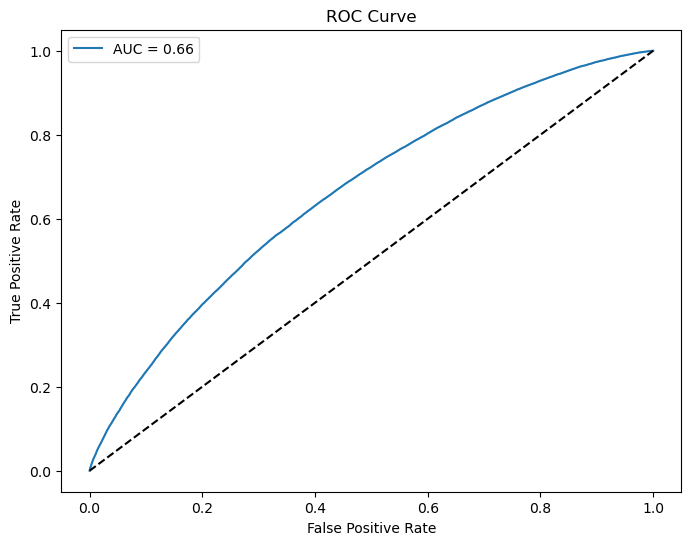

In [18]:
# Fit a Logistic Regression model on the training data
lr_model = LogisticRegression(penalty=None, max_iter=1000, class_weight='balanced')
lr_model.fit(X_train_woes, y_train_woes)
y_pred_proba_lr = lr_model.predict_proba(X_test_woes)[:, 1]

# Plot ROC curve with AUC score
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test_woes, y_pred_proba_lr)
roc_auc_lr = roc_auc_score(y_test_woes, y_pred_proba_lr)
plt.figure(figsize=(8, 6))
ax_lr = sns.lineplot(x=fpr_lr, y=tpr_lr, label='AUC = %0.2f' % roc_auc_lr)
plt.plot([0, 1], [0, 1], 'k--') # Add a diagonal dashed line for reference
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

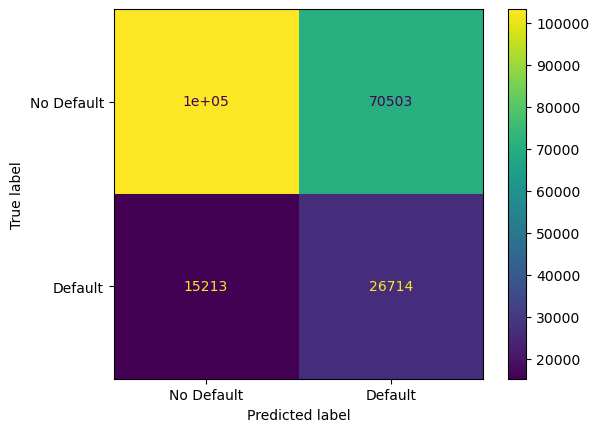

In [ ]:
# Determining KS optimal threshold and confusion matrix for the model for this threshold
ks_threshold_lr = np.argmax(tpr_lr - fpr_lr)
y_pred_lr = (y_pred_proba_lr >= thresholds_lr[ks_threshold_lr]).astype(int)
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['No Default', 'Default'])
disp.plot()

In [ ]:
# Computing precision, accuracy, recall and f1 scores
precision_lr = precision_score(y_test_woes, y_pred_lr)
accuracy_lr = accuracy_score(y_test_woes, y_pred_lr)
recall_lr = recall_score(y_test_woes, y_pred_lr)
f1_lr = f1_score(y_test_woes, y_pred_lr)
print(f'Precision: {precision_lr}')
print(f'Accuracy: {accuracy_lr}')
print(f'Recall: {recall_lr}')
print(f'F1 Score: {f1_lr}')

Precision: 0.27478733143380274
Accuracy: 0.6024838959509157
Recall: 0.6371550552150166
F1 Score: 0.3839763123095498


In [ ]:
# Examining model parameters
lr_model_coefficients = lr_model.coef_
lr_model_intercept = lr_model.intercept_
lr_model_variables = X_train_woes.columns
model_parameters = pd.DataFrame({'Variable': lr_model_variables, 'Coefficient': lr_model_coefficients[0]})
model_parameters.loc[-1] = {'Variable': 'intercept', 'Coefficient': lr_model_intercept[0]}
model_parameters.index = model_parameters.index + 1
model_parameters = model_parameters.sort_index()
print(model_parameters)

            Variable  Coefficient
0          intercept     0.049427
1            revenue    -1.210339
2              dti_n    -0.672014
3          loan_amnt    -1.883166
4             fico_n    -0.962888
5            purpose    -0.564616
6   home_ownership_n    -0.881843
7           zip_code    -0.929684
8              title    -0.396594
9  unemployment_rate    -0.610636


In [ ]:
# Compute VIFs for the training data. Is there multicollinearity?
X_train_plus = sm.add_constant(X_train_woes.astype(float))

vifs = pd.Series(
    [variance_inflation_factor(X_train_plus.values, i) for i in range(X_train_plus.shape[1])],
    index=X_train_plus.columns
)
print(vifs.drop("const").sort_values(ascending=False))

title                1.757978
purpose              1.499984
revenue              1.412546
loan_amnt            1.285725
unemployment_rate    1.272872
dti_n                1.096659
home_ownership_n     1.094905
fico_n               1.033574
zip_code             1.015337
dtype: float64


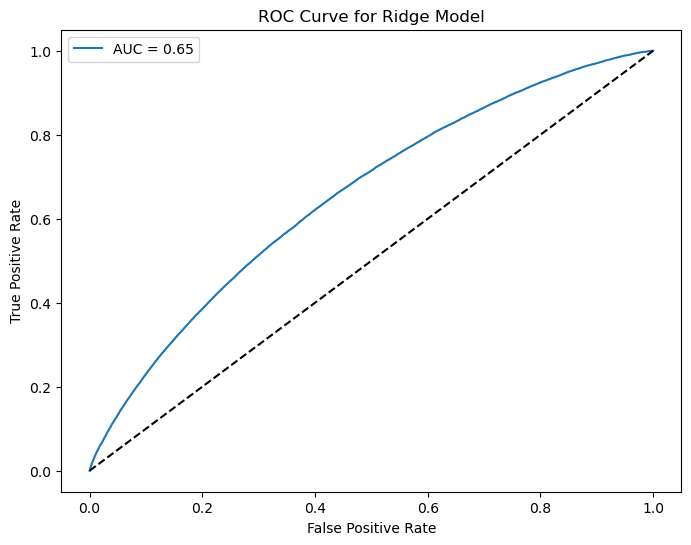

In [ ]:
# Fitting a heavily penalised ridge logistic regression model (fixed C=0.0001).
# Does reducing the effective model complexity reduce overfitting and improve out-of-sample performance?

lr_ridge_model = LogisticRegression(C=0.0001, max_iter=1000, penalty='l2', solver='lbfgs', class_weight='balanced')
lr_ridge_model.fit(X_train_woes, y_train_woes)
y_pred_proba_ridge = lr_ridge_model.predict_proba(X_test_woes)[:, 1]

# Plot ROC curve with AUC score
fpr_ridge, tpr_ridge, thresholds_ridge = roc_curve(y_test_woes, y_pred_proba_ridge)
roc_auc_ridge = roc_auc_score(y_test_woes, y_pred_proba_ridge)
plt.figure(figsize=(8, 6))
ax_ridge = sns.lineplot(x=fpr_ridge, y=tpr_ridge, label='AUC = %0.2f' % roc_auc_ridge)
plt.plot([0, 1], [0, 1], 'k--') # Add a diagonal dashed line for reference
plt.title('ROC Curve for Ridge Model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

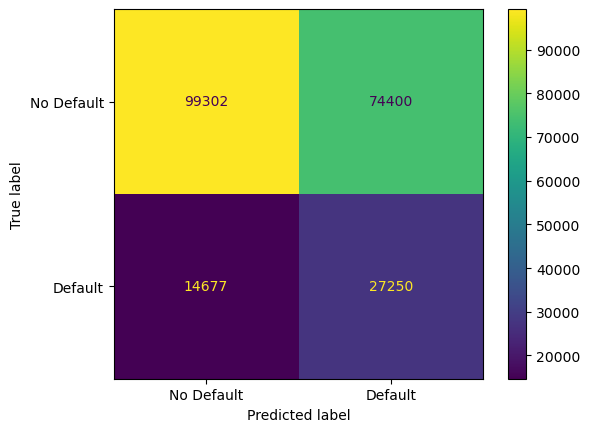

In [ ]:
# Determining KS optimal threshold and confusion matrix for the ridge model for this threshold
ks_threshold_ridge = np.argmax(tpr_ridge - fpr_ridge)
y_pred_proba_ridge = (y_pred_proba_ridge >= thresholds_ridge[ks_threshold_ridge]).astype(int)
cm_ridge = confusion_matrix(y_test_woes, y_pred_proba_ridge)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_ridge, display_labels=['No Default', 'Default'])
disp.plot()

In [ ]:
# Computing precision, accuracy, recall and f1 scores for the ridge model
precision_ridge = precision_score(y_test_woes, y_pred_proba_ridge)
accuracy_ridge = accuracy_score(y_test_woes, y_pred_proba_ridge)
recall_ridge = recall_score(y_test_woes, y_pred_proba_ridge)
f1_ridge = f1_score(y_test_woes, y_pred_proba_ridge)
print(f'Precision: {precision_ridge}')
print(f'Accuracy: {accuracy_ridge}')
print(f'Recall: {recall_ridge}')
print(f'F1 Score: {f1_ridge}')

Precision: 0.2680767338908018
Accuracy: 0.5868969387234556
Recall: 0.6499391800033392
F1 Score: 0.3795872597978785


In [ ]:
# Examining model parameters
lr_ridge_model_coefficients = lr_ridge_model.coef_
lr_ridge_model_intercept = lr_ridge_model.intercept_
lr_ridge_model_variables = X_train_woes.columns
model_parameters_ridge = pd.DataFrame({'Variable': lr_ridge_model_variables, 'Coefficient': lr_ridge_model_coefficients[0]})
model_parameters_ridge.loc[-1] = {'Variable': 'intercept', 'Coefficient': lr_ridge_model_intercept[0]}
model_parameters_ridge.index = model_parameters_ridge.index + 1
model_parameters_ridge = model_parameters_ridge.sort_index()
print(model_parameters_ridge)

            Variable  Coefficient
0          intercept     0.024191
1            revenue    -0.309709
2              dti_n    -0.525855
3          loan_amnt    -0.478872
4             fico_n    -0.674175
5            purpose    -0.196374
6   home_ownership_n    -0.305956
7           zip_code    -0.391141
8              title    -0.329959
9  unemployment_rate    -0.228342


In [ ]:
# Comparing accuracy scores (with default threshold of 0.5) from X_train to X_test between the two models
accuracy_lr_ridge_train = lr_ridge_model.score(X_train_woes, y_train_woes)
accuracy_lr_ridge_test = lr_ridge_model.score(X_test_woes, y_test_woes)
accuracy_lr_train = lr_model.score(X_train_woes, y_train_woes)
accuracy_lr_test = lr_model.score(X_test_woes, y_test_woes)

train_test_accuracies = pd.DataFrame({'Model': ['Ridge', 'Unpenalised'], 'Train': [accuracy_lr_ridge_train, accuracy_lr_train], 'Test': [accuracy_lr_ridge_test, accuracy_lr_test]})
train_test_accuracies.set_index('Model', inplace=True)
print(train_test_accuracies)

                Train      Test
Model                          
Ridge        0.584950  0.586085
Unpenalised  0.600709  0.602141


In [ ]:
# Creating DataFrames of bin labels and scores to build scorecard for unpenalised model
bin_labels = {}
bin_scores = {}

for column in X_train_woes.columns:

    coefficient = model_parameters.loc[model_parameters['Variable'] == column, 'Coefficient'].iloc[0]

    # Quantiles for continuous variables (12 bins, matching the WoE cell)
    if column in conts_columns:

        quantiles = [X_train[column].quantile(i/num_bins) for i in range(num_bins+1)]
        upper_bounds = quantiles[1:]

        # WoE for each bin: read off any training row falling in that bin
        woes = []
        for i in range(num_bins):
            in_bin = (X_train[column] <= quantiles[i+1]) & (X_train[column] > quantiles[i])
            woes.append(X_train_woes.loc[in_bin, column].iloc[0] if in_bin.any() else np.nan)

        bin_labels[column] = pd.Series(upper_bounds)
        bin_scores[column] = pd.Series([coefficient * w for w in woes])

    # Categories for discrete variables: read the category -> WoE map
    # directly off the raw/WoE column pair, training data only
    if column in disc_columns:

        pairs = (pd.DataFrame({'label': X_train[column], 'woe': X_train_woes[column]})
                   .dropna(subset=['label'])
                   .drop_duplicates(subset='label')
                   .sort_values('woe')
                   .reset_index(drop=True))

        bin_labels[column] = pairs['label']
        bin_scores[column] = coefficient * pairs['woe']

# Ragged concat: every column keeps its full length, shorter ones are NaN-padded.
# (Column-by-column assignment into a DataFrame aligns on the existing index and
# silently truncates - this was the source of the 12-row zip_code/title bug.)
bin_labels_df = pd.concat(bin_labels, axis=1)
bin_scores_df = pd.concat(bin_scores, axis=1)

# Write CSV files for scorecard building in Excel
bin_labels_df.to_csv(f'{REPO_ROOT}/Scorecard/scorecard_bin_labels.csv')
bin_scores_df.to_csv(f'{REPO_ROOT}/Scorecard/scorecard_bin_scores.csv')

In [ ]:
# PSI analysis using X_train and X_test_psi probabilities
y_pred_train_proba_lr = lr_model.predict_proba(X_train_woes)[:, 1]
y_pred_psi_proba_lr = lr_model.predict_proba(X_test_psi_woes)[:, 1]
y_psi_df = pd.DataFrame({'pred_proba': y_pred_psi_proba_lr})
y_pred_train_total = len(list(y_pred_train_proba_lr))
y_pred_psi_total = len(list(y_pred_psi_proba_lr))

bin_props_psi_list = []
bin_props_train_list = []
psi_list = []

# Obtain PSI values for different numbers of bins (derived from X_train probability quantiles)
for num_bins in range(1, 21):

    # List for y_pred_psi counts in quantiles of y_pred_train
    bin_props = []

    for i in range(num_bins):

        # Compute lower and upper bounds for bin, calculate proportions in range
        lower_bound = np.quantile(y_pred_train_proba_lr, i/num_bins)
        upper_bound = np.quantile(y_pred_train_proba_lr, (i+1)/num_bins)
        filter = (y_psi_df['pred_proba'] >= lower_bound) & (y_psi_df['pred_proba'] < upper_bound)
        bin_props.append(y_psi_df[filter].shape[0] / y_pred_psi_total)
        
    # Store proportion lists for PSI calculation
    bin_props_psi_list.append(bin_props)
    bin_props_train_list.append([1 / num_bins for j in range(num_bins)])

# Compute PSIs
for k in range(20):

    new_p = np.array(bin_props_psi_list[k])
    old_p = np.array(bin_props_train_list[k])
    psi = ((new_p - old_p) * np.log(new_p / old_p)).sum().astype(float)
    psi_list.append(psi)

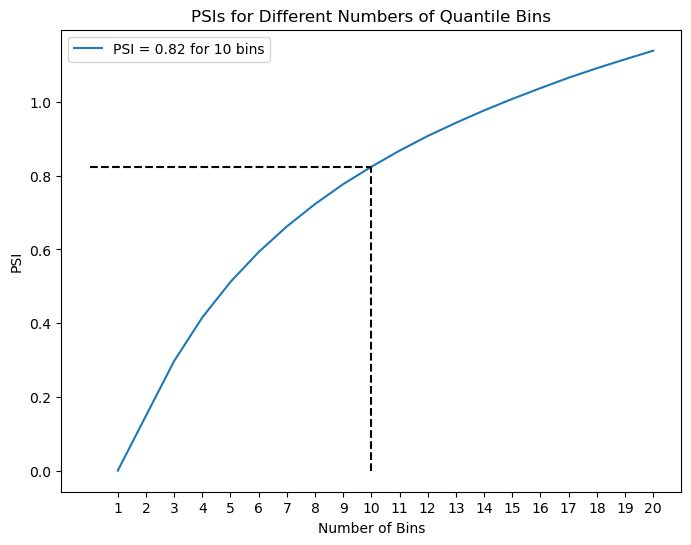

In [ ]:
# Plot of PSI against number of bins
plt.figure(figsize=(8, 6))
psi_bins_plot = sns.lineplot(x=range(1, 21), y=psi_list, label='PSI = %0.2f for 10 bins' % psi_list[9])

plt.title('PSIs for Different Numbers of Quantile Bins')
plt.xlabel('Number of Bins')
plt.ylabel('PSI')
plt.xticks(range(1, 21))
plt.plot([10, 10], [0, psi_list[9]], 'k--')
plt.plot([0, 10], [psi_list[9], psi_list[9]], 'k--')
plt.show()

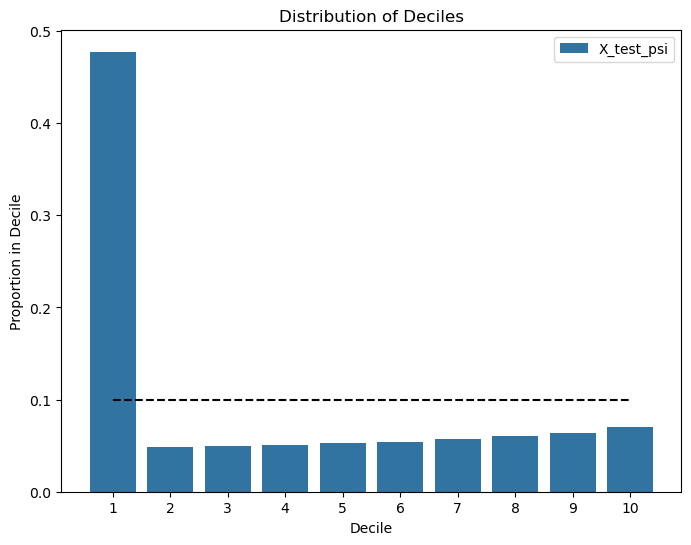

In [ ]:
plt.figure(figsize=(8, 6))
psi_10_bins_plot = sns.barplot(x=range(1, 11), y=bin_props_psi_list[9], label='X_test_psi')
plt.title('Distribution of Deciles')
plt.xlabel('Decile')
plt.ylabel('Proportion in Decile')
plt.xticks(range(10))
plt.plot([0, 9], [bin_props_train_list[9][0], bin_props_train_list[9][0]], 'k--')
plt.show()

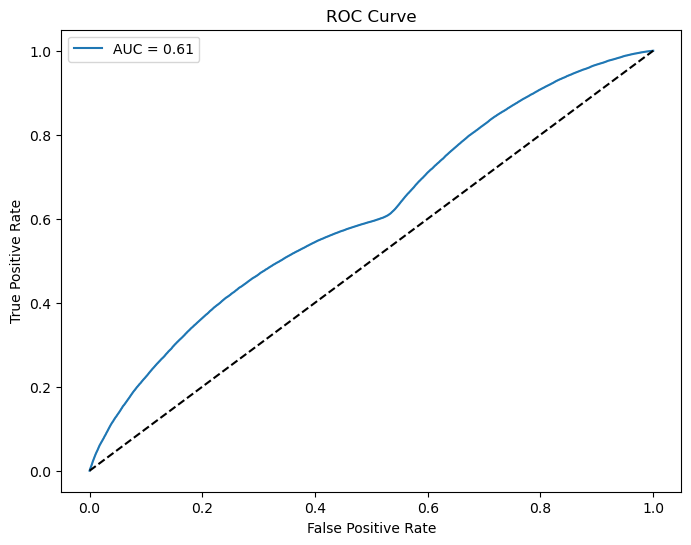

In [19]:
# Predict defaults for holdout X_test_psi sample
y_pred_proba_lr_psi = lr_model.predict_proba(X_test_psi_woes)[:, 1]

# Plot ROC curve with AUC score
fpr_lr_psi, tpr_lr_psi, thresholds_lr_psi = roc_curve(y_test_psi_woes, y_pred_proba_lr_psi)
roc_auc_lr_psi = roc_auc_score(y_test_psi_woes, y_pred_proba_lr_psi)
plt.figure(figsize=(8, 6))
ax_lr = sns.lineplot(x=fpr_lr_psi, y=tpr_lr_psi, label='AUC = %0.2f' % roc_auc_lr_psi)
plt.plot([0, 1], [0, 1], 'k--') # Add a diagonal dashed line for reference
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

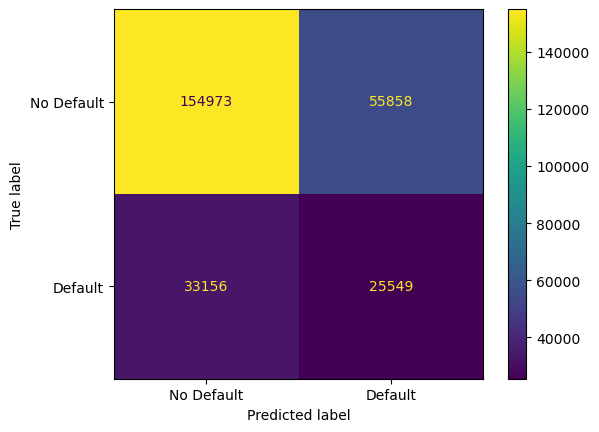

In [20]:
# Determining KS optimal threshold and confusion matrix for the holdout PSI sample for this threshold
ks_threshold_lr_psi = np.argmax(tpr_lr_psi - fpr_lr_psi)
y_pred_proba_lr_psi = (y_pred_proba_lr_psi >= thresholds_lr_psi[ks_threshold_lr_psi]).astype(int)
cm_lr_psi = confusion_matrix(y_test_psi_woes, y_pred_proba_lr_psi)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr_psi, display_labels=['No Default', 'Default'])
disp.plot()

In [21]:
# Computing precision, accuracy, recall and f1 scores for the PSI sample
precision_lr_psi = precision_score(y_test_psi_woes, y_pred_proba_lr_psi)
accuracy_lr_psi = accuracy_score(y_test_psi_woes, y_pred_proba_lr_psi)
recall_lr_psi = recall_score(y_test_psi_woes, y_pred_proba_lr_psi)
f1_lr_psi = f1_score(y_test_psi_woes, y_pred_proba_lr_psi)
print(f'Precision: {precision_lr_psi}')
print(f'Accuracy: {accuracy_lr_psi}')
print(f'Recall: {recall_lr_psi}')
print(f'F1 Score: {f1_lr_psi}')

Precision: 0.3138427899320697
Accuracy: 0.6697509794609996
Recall: 0.4352099480453113
F1 Score: 0.36469395911841956
